# Bicycle Trip: New York City to Key West

**Sebastian Perdomo | IS 362 | Week 3**

,Miles Ridden,Cumulative Miles
Day,,
1,55,55
2,65,120
3,72,192
4,68,260
5,0,260
6,81,341
7,77,418
8,63,481
9,70,551


Total distance:        1557 miles
Days on the road:      25
Days spent riding:     22
Rest days:             3 (days [5, 12, 19] )
Average, all days:     62.3 miles
Average, riding days:  70.8 miles
Longest day:           88 miles on day 17
Shortest riding day:   55 miles on day 1


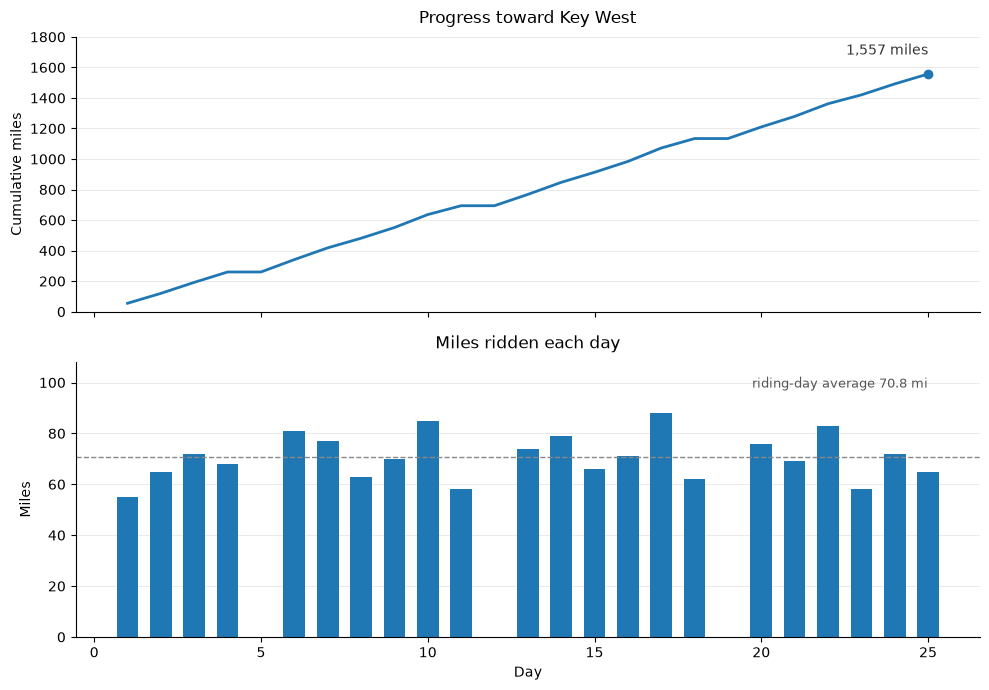

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Odometer readings logged at the end of each day
odometer_log = [55, 120, 192, 260, 260, 341, 418, 481, 551, 636, 694, 694,
                768, 847, 913, 984, 1072, 1134, 1134, 1210, 1279, 1362,
                1420, 1492, 1557]

cumulative_miles = pd.Series(
    odometer_log,
    index=range(1, len(odometer_log) + 1),
    name="Cumulative Miles"
)
cumulative_miles.index.name = "Day"

# 2. Daily miles are the gaps between readings.
daily_miles = (cumulative_miles
               .diff()
               .fillna(cumulative_miles.iloc[0])
               .astype(int))
daily_miles.name = "Miles Ridden"

# 3. Both measures side by side
trip = pd.DataFrame({
    "Miles Ridden": daily_miles,
    "Cumulative Miles": cumulative_miles
})
display(trip)

# 4. Trip summary
riding_days = daily_miles[daily_miles > 0]
rest_days = daily_miles[daily_miles == 0]

print("Total distance:       ", daily_miles.sum(), "miles")
print("Days on the road:     ", len(daily_miles))
print("Days spent riding:    ", len(riding_days))
print("Rest days:            ", len(rest_days), "(days", list(rest_days.index), ")")
print("Average, all days:    ", round(daily_miles.mean(), 1), "miles")
print("Average, riding days: ", round(riding_days.mean(), 1), "miles")
print("Longest day:          ", daily_miles.max(), "miles on day", daily_miles.idxmax())
print("Shortest riding day:  ", riding_days.min(), "miles on day", riding_days.idxmin())

# 5. Charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(cumulative_miles.index, cumulative_miles.values,
         color="#1f77b4", linewidth=2)
ax1.plot(cumulative_miles.index[-1], cumulative_miles.iloc[-1],
         marker="o", markersize=6, color="#1f77b4")
ax1.set_ylim(0, 1800)
ax1.set_title("Progress toward Key West", fontsize=12, pad=10)
ax1.set_ylabel("Cumulative miles")
ax1.annotate(f"{cumulative_miles.iloc[-1]:,} miles",
             xy=(cumulative_miles.index[-1], cumulative_miles.iloc[-1]),
             xytext=(0, 14), textcoords="offset points",
             ha="right", fontsize=10, color="#333333")

ax2.bar(daily_miles.index, daily_miles.values, color="#1f77b4", width=0.65)
ax2.set_ylim(0, 108)
ax2.axhline(riding_days.mean(), color="#888888", linewidth=1, linestyle="--", zorder=1)
ax2.text(len(daily_miles), 98,
         f"riding-day average {riding_days.mean():.1f} mi",
         ha="right", fontsize=9, color="#555555")
ax2.set_title("Miles ridden each day", fontsize=12, pad=10)
ax2.set_ylabel("Miles")
ax2.set_xlabel("Day")

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.3, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## What each section does

1. **Build the Series.** Loads the odometer log into a pandas Series indexed by
   day number.
2. **Daily miles.** `.diff()` subtracts each reading from the one before it to
   get that day's ride.
3. **Table.** Puts daily and cumulative miles side by side, one row per day.
4. **Summary.** Totals, averages, and the longest and shortest days.
5. **Charts.** Cumulative progress as a line and miles per day as bars, on a
   shared day axis.